In [1]:
from torch.utils.data import DataLoader, Dataset

from LightCurve import test_train_lc
from functions.model_analysis_functions import *

/Users/aaryanthusoo/Desktop/UCL/Research/.venv/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
from sklearn.model_selection import train_test_split
import numpy as np
import torch

num_lc = 7500
lc_types = [0, 1, 2]
per_types = [0.333, 0.333, 0.334]

# First split: train/test
X_train_full, X_test, y_train_full, y_test = test_train_lc(
    num_lc=num_lc,
    lc_types=lc_types,
    per_types=per_types,
    check=None
)

# Second split: train/validation from the training portion
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,              # 20% of the training portion becomes validation
    stratify=y_train_full,
    random_state=42
)

# Normalize each light curve independently
X_train = (X_train - np.median(X_train, axis=1, keepdims=True)) / (np.std(X_train, axis=1, keepdims=True) + 1e-8)
X_val   = (X_val   - np.median(X_val,   axis=1, keepdims=True)) / (np.std(X_val,   axis=1, keepdims=True) + 1e-8)
X_test  = (X_test  - np.median(X_test,  axis=1, keepdims=True)) / (np.std(X_test,  axis=1, keepdims=True) + 1e-8)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_val   = torch.tensor(X_val,   dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val,   dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:  ", X_val.shape, y_val.shape)
print("Test shape: ", X_test.shape, y_test.shape)

Train shape: torch.Size([4800, 1, 4894]) torch.Size([4800])
Val shape:   torch.Size([1200, 1, 4894]) torch.Size([1200])
Test shape:  torch.Size([1501, 1, 4894]) torch.Size([1501])


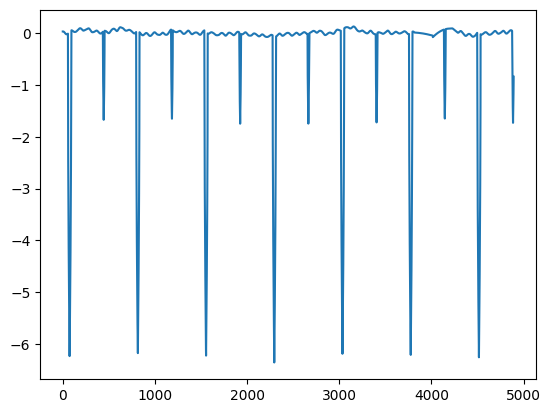

In [3]:

plt.plot(X_train[200][0])

In [4]:
class LightCurveDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

from torch.utils.data import TensorDataset, DataLoader

batch_size = 32

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val, y_val)
test_ds  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN1D(nn.Module):
    def __init__(self, n_points, conv_dropout=0.20, fc_dropout=0.50):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5)
        self.pool = nn.MaxPool1d(2)

        self.dropout1 = nn.Dropout1d(conv_dropout)
        self.dropout2 = nn.Dropout1d(conv_dropout)
        self.dropout_fc = nn.Dropout(fc_dropout)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_points)
            z = self.pool(F.relu(self.conv1(dummy)))
            z = self.dropout1(z)
            z = self.pool(F.relu(self.conv2(z)))
            z = self.dropout2(z)
            n_features = z.shape[1] * z.shape[2]

        self.fc1 = nn.Linear(n_features, 64)
        self.fc2 = nn.Linear(64, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout1(x)

        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout2(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)

        return self.fc2(x)

In [6]:
model = CNN1D(n_points=X_train.shape[-1], conv_dropout=0.20, fc_dropout=0.50)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [7]:
from tqdm.notebook import tqdm
import torch
import copy

num_epochs = 10
patience = 3

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for X_batch, y_batch in progress_bar:
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct_train += (preds == y_batch).sum().item()
        total_train += y_batch.size(0)

        progress_bar.set_postfix({
            "batch_loss": f"{loss.item():.4f}",
            "avg_loss": f"{running_loss / (progress_bar.n + 1):.4f}"
        })

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct_val += (preds == y_batch).sum().item()
            total_val += y_batch.size(0)

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = correct_val / total_val

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model with validation loss: {best_val_loss:.4f}")

Epoch 1/10:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 0.9616 | Train Acc: 0.5192 | Val Loss: 0.7462 | Val Acc: 0.6417


Epoch 2/10:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 2/10 | Train Loss: 0.7395 | Train Acc: 0.6469 | Val Loss: 0.6555 | Val Acc: 0.7267


Epoch 3/10:   0%|          | 0/150 [00:00<?, ?it/s]

...

Epoch 5/10 | Train Loss: 0.4973 | Train Acc: 0.7885 | Val Loss: 0.6232 | Val Acc: 0.7192


Epoch 6/10:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 6/10 | Train Loss: 0.4433 | Train Acc: 0.8183 | Val Loss: 0.6165 | Val Acc: 0.7458


Epoch 7/10:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 7/10 | Train Loss: 0.4160 | Train Acc: 0.8398 | Val Loss: 0.6340 | Val Acc: 0.7317
Early stopping triggered at epoch 7.
Loaded best model with validation loss: 0.5952


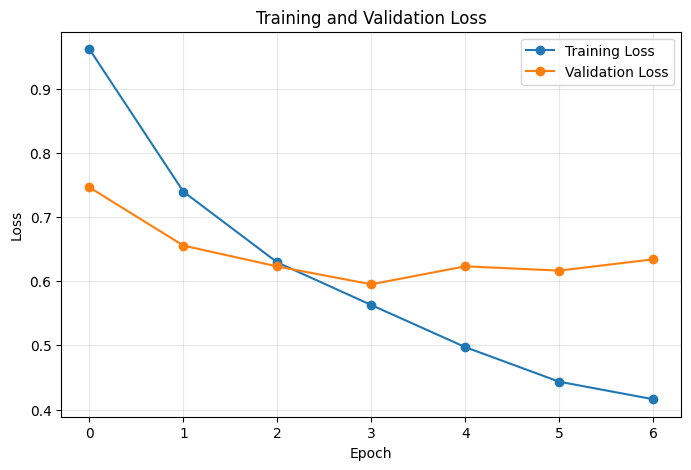

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker='o', label='Training Loss')
plt.plot(val_losses, marker='o', label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

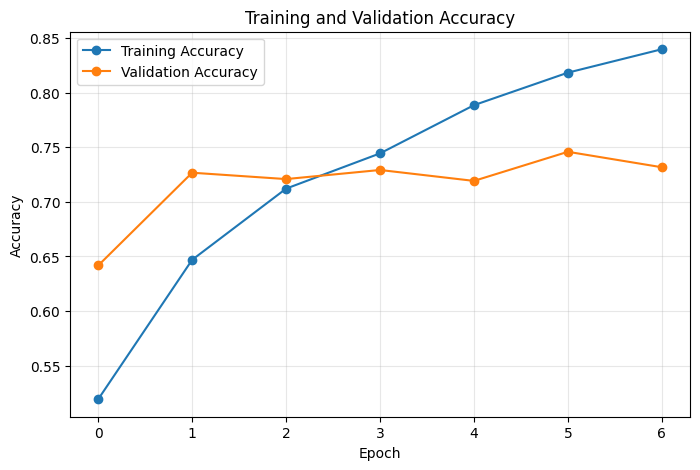

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, marker='o', label='Training Accuracy')
plt.plot(val_accuracies, marker='o', label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
all_preds, all_true, all_conf = get_batch_information(model, test_loader)

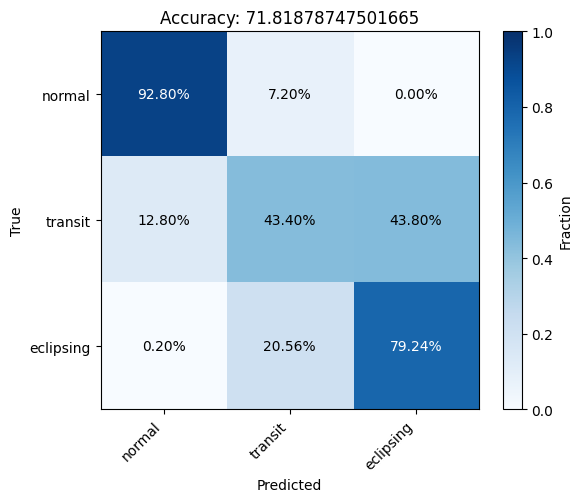

In [11]:
plot_confusion_matrix(all_true, all_preds)

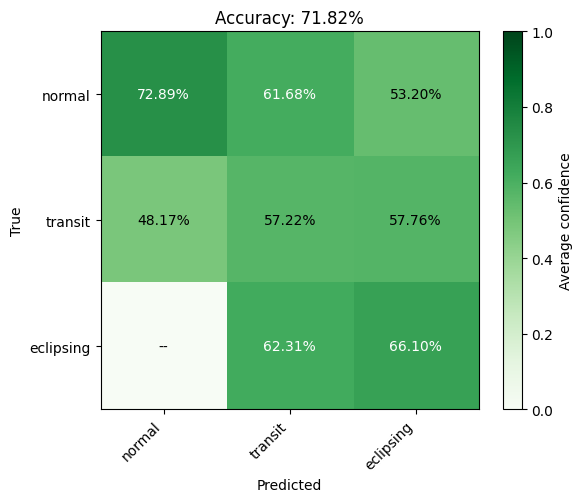

In [12]:
plot_confidence_confusion_matrix(all_preds, all_true, all_conf)

In [13]:
threshold = 0.6

low_conf_idx = torch.where(all_conf < threshold)[0]

print("Number of low-confidence results:", len(low_conf_idx))
print("Indices:", low_conf_idx.tolist())

Number of low-confidence results: 625
Indices: [0, 1, 4, 5, 10, 11, 13, 15, 16, 25, 26, 27, 29, 33, 34, 35, 37, 38, 41, 42, 44, 45, 47, 48, 49, 54, 59, 60, 62, 66, 68, 70, 71, 75, 85, 88, 89, 91, 92, 94, 96, 97, 107, 108, 109, 110, 111, 112, 113, 115, 117, 118, 119, 120, 124, 127, 129, 132, 133, 134, 139, 143, 144, 146, 147, 151, 152, 153, 154, 155, 156, 157, 158, 160, 166, 167, 169, 171, 172, 174, 175, 177, 178, 184, 185, 188, 189, 190, 191, 193, 194, 196, 205, 207, 209, 212, 214, 215, 217, 219, 220, 222, 225, 228, 229, 230, 232, 233, 236, 240, 242, 243, 250, 253, 256, 259, 260, 268, 271, 275, 276, 280, 281, 282, 283, 285, 291, 292, 293, 294, 295, 298, 299, 302, 303, 304, 307, 308, 311, 316, 320, 321, 323, 329, 331, 333, 334, 337, 344, 346, 347, 350, 356, 358, 360, 364, 366, 367, 373, 375, 376, 379, 382, 388, 390, 392, 397, 404, 405, 406, 407, 408, 409, 416, 419, 420, 421, 422, 423, 425, 426, 428, 432, 433, 435, 436, 438, 440, 442, 443, 444, 446, 447, 448, 449, 450, 452, 455, 456, 457

In [14]:
incorrect_ordered = get_all_incorrect(all_preds, all_true, lc_types)

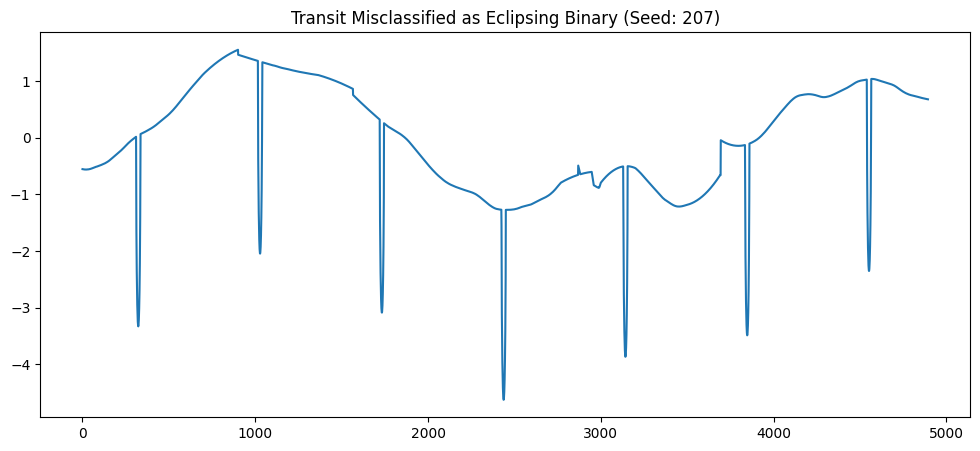

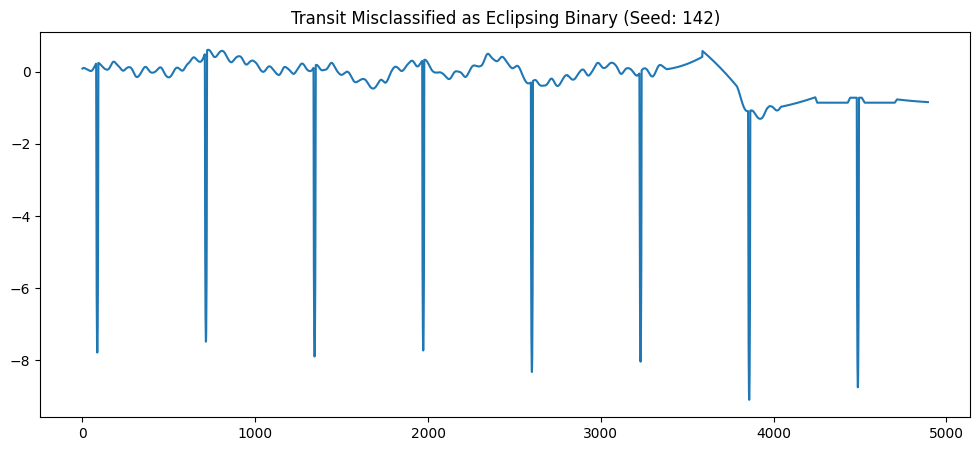

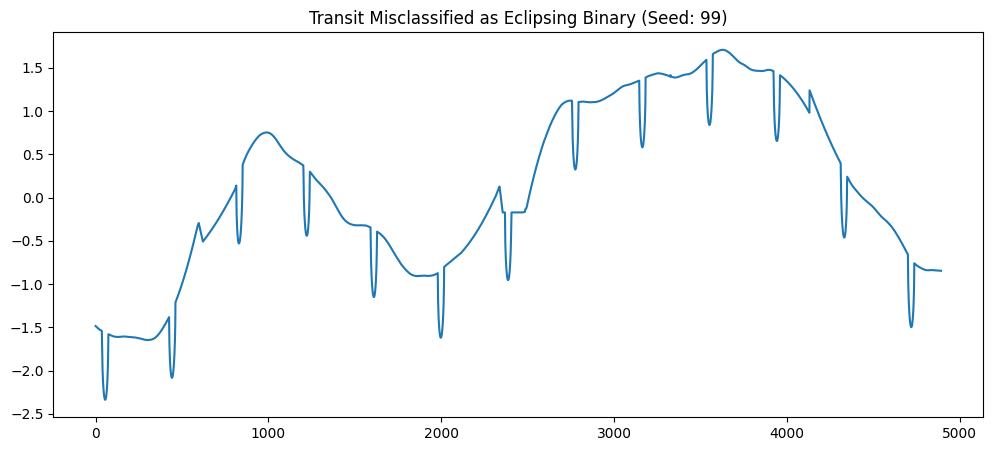

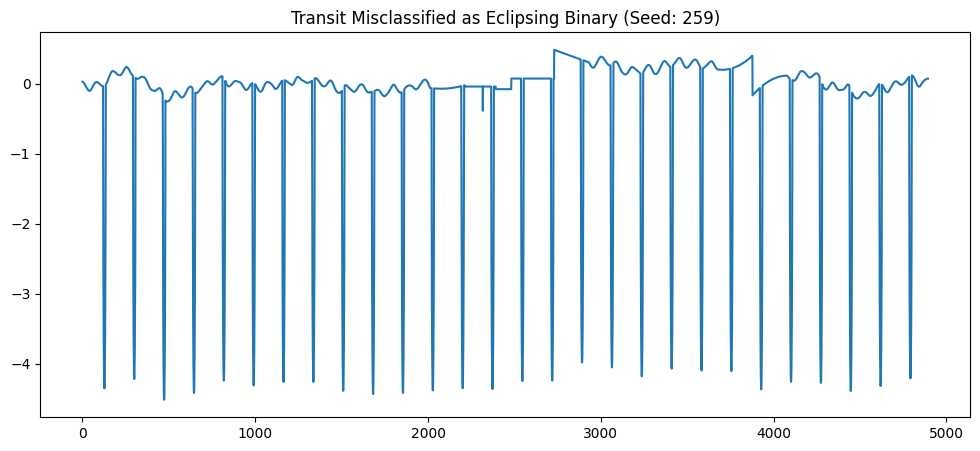

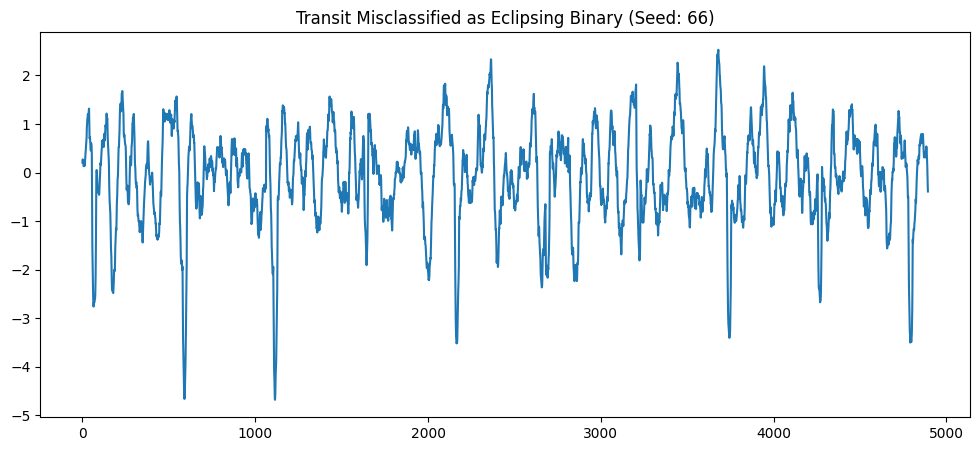

In [18]:
for _ in range(0, 5):
    plot_misclassified(X_test, incorrect_ordered, (1, 2))

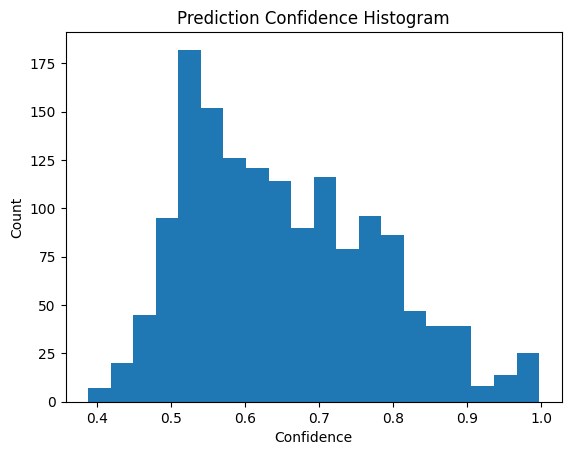

In [16]:
plot_confidence_hist(all_conf)

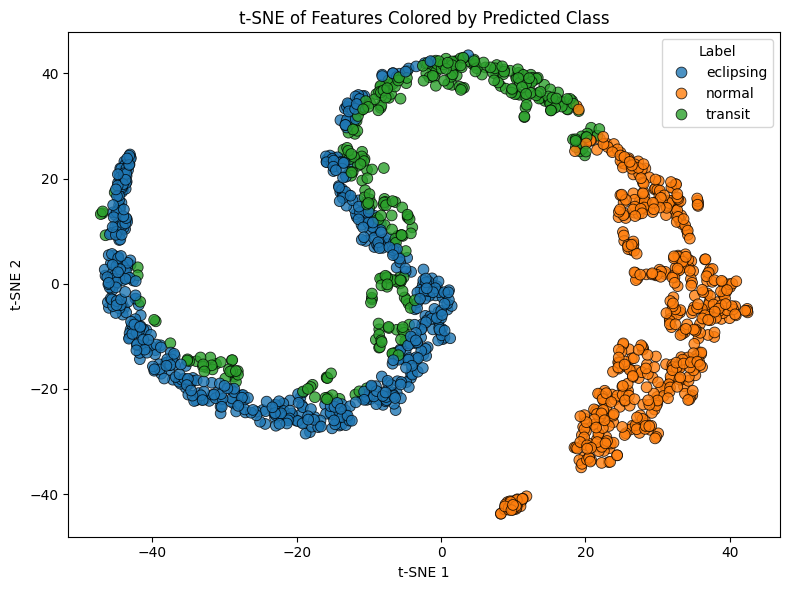

In [17]:
names = {0: "normal",
         1: "transit",
         2: "eclipsing"}
plot_tsne_classifications(model, test_loader, class_names=names)